# Results: finding nine landmarks on cat faces

This notebook is where I keep the results of my landmark experiments. The question I am trying to answer:
**does masked-autoencoder pretraining on unlabeled cat photos help a Vision Transformer find landmarks?**

To answer it I need two runs that differ in only one thing, the starting weights:

| Run | Starting weights | Status |
|---|---|---|
| `pose_scratch` | random | done |
| `pose_mae` | the encoder from MAE pretraining | pretraining still running |

So far only the baseline is finished. I wrote every cell below to loop over whatever runs are in `results/`, so
once the MAE run is done I can rerun the notebook and the two runs will sit side by side on the same plots.

## How I measure error

Every face has nine landmarks: two eyes, the mouth, and three points on each ear. For each landmark I take the
distance between my prediction and the hand-placed point, and divide it by the distance between the two eyes.
This **normalised mean error (NME)** makes faces of different sizes comparable.

A quick example to make the number concrete: if the eyes are 100 pixels apart and my mouth prediction is off by
6 pixels, that landmark's error is 6 / 100 = 0.06. A face's NME is the average over its nine landmarks.

I also report a **failure rate**: the share of faces whose NME is above 0.1, i.e. faces where the points are,
on average, off by more than a tenth of the eye distance.

All numbers here are on the **validation split** (1,000 faces). I am keeping the test split untouched until both
runs are finished, and I will evaluate it once at the end.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
LABELS = {"pose_scratch": "from scratch", "pose_mae": "from MAE"}

runs = {}
for folder in sorted(RESULTS.glob("pose_*")):
    runs[folder.name] = {
        "config": json.loads((folder / "config.json").read_text()),
        "metrics": [json.loads(line) for line in (folder / "metrics.jsonl").read_text().splitlines()],
        "val": json.loads((folder / "eval_val.json").read_text()),
    }
print("runs found:", list(runs))

runs found: ['pose_scratch']


## The setup

Both runs use the same ViT-Small encoder (12 blocks, width 384, 16×16 patches on a 224×224 crop) with a small
ViTPose-style decoder that turns patch features into one heat map per landmark. I read each landmark off its heat
map with a soft-argmax (the expected position under the heat map) rather than the peak, so the model is trained
directly on the distance to the true point.

The training settings, straight from the run's config:

In [2]:
for name, run in runs.items():
    cfg = run["config"]["finetune"]
    minutes = sum(m["seconds"] for m in run["metrics"]) / 60
    print(f"{name} ({LABELS.get(name, name)})")
    print(f"  starting weights : {run['config']['init'] or 'random'}")
    print(f"  hardware         : {run['config'].get('hardware', 'unknown')}")
    faces = run["config"]["splits"]["train"]
    print(f"  epochs × batch   : {cfg['epochs']} × {cfg['batch']}  ({faces:,} training faces)")
    print(f"  learning rate    : {cfg['base_lr']} × batch/256, layer decay {cfg['layer_decay']}, "
          f"weight decay {cfg['weight_decay']}, drop path {cfg['drop_path']}")
    print(f"  augmentation     : zoom {cfg['zoom'][0]}-{cfg['zoom'][1]} face widths, "
          f"turn ±{cfg['turn_deg']}°, shift ±{cfg['shift']:.0%}, mirror, colour jitter")
    print(f"  training time    : {minutes:.0f} minutes")

pose_scratch (from scratch)
  starting weights : random
  hardware         : Kaggle, 1 x NVIDIA Tesla T4, float32
  epochs × batch   : 100 × 64  (7,996 training faces)
  learning rate    : 0.001 × batch/256, layer decay 0.75, weight decay 0.05, drop path 0.1
  augmentation     : zoom 1.0-2.0 face widths, turn ±25.0°, shift ±10%, mirror, colour jitter
  training time    : 187 minutes


## Learning curves

The first thing I check is whether training actually converged, and whether the validation error is still
falling when it stops.

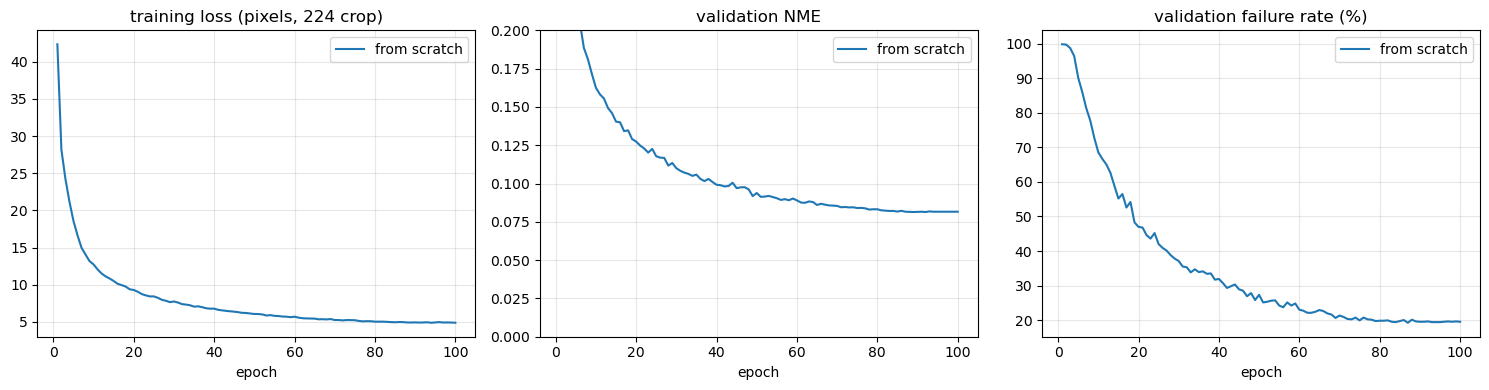

from scratch: best validation NME 0.0814 at epoch 89; epoch 40: 0.0992, epoch 80: 0.0832, last: 0.0816


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, run in runs.items():
    m = run["metrics"]
    epochs = [r["epoch"] for r in m]
    label = LABELS.get(name, name)
    axes[0].plot(epochs, [r["train_px"] for r in m], label=label)
    axes[1].plot(epochs, [r["val_nme"] for r in m], label=label)
    axes[2].plot(epochs, [100 * r["val_failure_rate"] for r in m], label=label)
titles = ["training loss (pixels, 224 crop)", "validation NME", "validation failure rate (%)"]
for ax, title in zip(axes, titles, strict=True):
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()
axes[1].set_ylim(0, 0.2)
plt.tight_layout()
plt.show()

for name, run in runs.items():
    m = run["metrics"]
    best = min(m, key=lambda r: r["val_nme"])
    print(f"{LABELS.get(name, name)}: best validation NME {best['val_nme']:.4f} at epoch {best['epoch']}; "
          f"epoch 40: {m[39]['val_nme']:.4f}, epoch 80: {m[79]['val_nme']:.4f}, last: {m[-1]['val_nme']:.4f}")

What I see in the baseline: the error drops fast in the first 20 epochs and then slows down a lot. Between
epoch 80 and the end it barely moves, so training longer would not buy much. The training loss is still going
down while the validation error is flat, which tells me the model has learned about as much as it can generalise
from 8,000 labeled faces when it starts from nothing. That plateau is exactly what pretraining is supposed to lift.

## Which landmarks are hard?

Averaging over nine points hides a lot, so here is the error of each landmark separately.

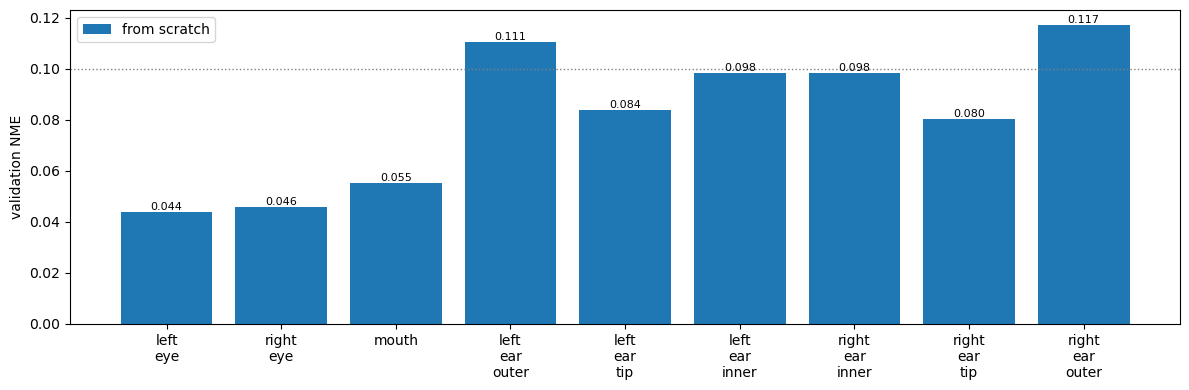

from scratch: NME 0.0814, failure rate 19.6% on 1,000 validation faces (best checkpoint)


In [4]:
names = list(next(iter(runs.values()))["val"]["nme_per_landmark"])
x = np.arange(len(names))
width = 0.8 / len(runs)
fig, ax = plt.subplots(figsize=(12, 4))
for k, (name, run) in enumerate(runs.items()):
    values = [run["val"]["nme_per_landmark"][n] for n in names]
    bars = ax.bar(x + k * width, values, width, label=LABELS.get(name, name))
    ax.bar_label(bars, fmt="%.3f", fontsize=8)
ax.set_xticks(x + width * (len(runs) - 1) / 2, [n.replace("_", "\n") for n in names])
ax.set_ylabel("validation NME")
ax.axhline(0.1, color="grey", linestyle=":", linewidth=1)
ax.legend()
plt.tight_layout()
plt.show()

for name, run in runs.items():
    v = run["val"]
    print(f"{LABELS.get(name, name)}: NME {v['nme']:.4f}, failure rate {v['failure_rate_0.1']:.1%} "
          f"on {v['faces']:,} validation faces (best checkpoint)")

The eyes are the easiest points by far, then the mouth. The ears are clearly harder, and among the ear points the
**outer and inner bases** are the worst, while the ear tips are in between.

My explanation: an eye has a sharp, high-contrast outline, so there is one obvious place to put the point. An ear
tip is at least a corner. But the base of an ear just fades into the fur of the head; there is no edge that says
"here". I suspect the human annotators did not agree with each other on these points either, so part of this error
may be noise in the labels rather than a mistake by the model.

## Looking at the predictions

Numbers are easy to misread, so I also look at the predictions. Below, the **dots are the hand-placed landmarks**
and the **crosses are the model's predictions**, on validation faces cut out the same way as during evaluation
(1.5 face widths around the face). The top rows are random faces; the bottom rows are the faces with the
**largest** error, because those are the ones that teach me something.

This cell needs the checkpoint (`runs/<run>/best.pt`) and the crop cache (`data/cache/cat`), which are too big for
git; without them it only prints a note, and the saved figure below stays as it was.

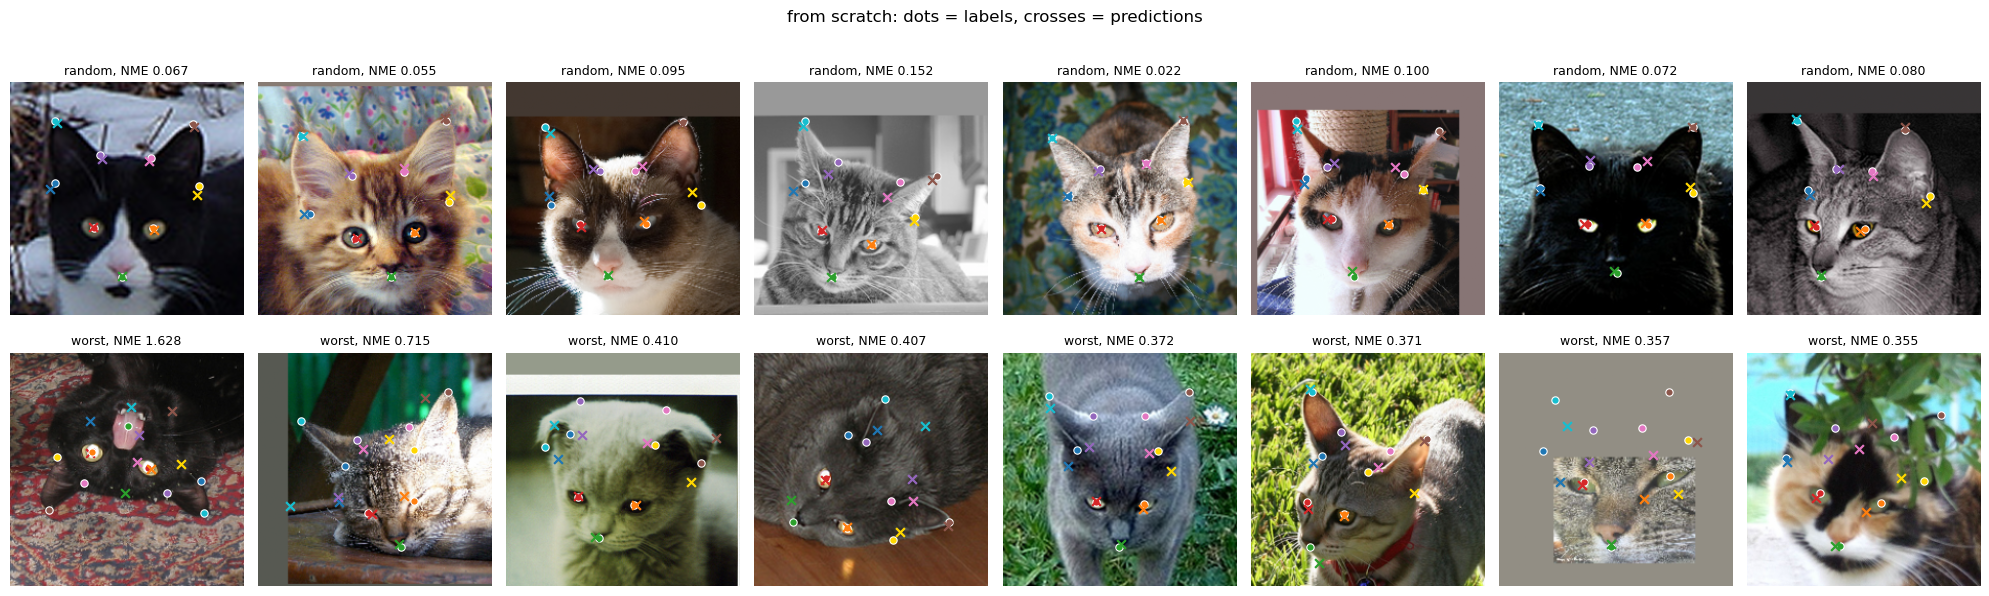

In [5]:
import sys

import torch

sys.path.insert(0, str(ROOT))
from catlandmarks import augment
from catlandmarks.finetune import Faces, FinetuneConfig, crops, load
from catlandmarks.pose import normalised_error
from catlandmarks.pretrain import MEAN, STD

COLOURS = ["tab:red", "tab:orange", "tab:green", "tab:blue", "tab:cyan", "tab:purple", "tab:pink", "tab:brown", "gold"]


def show_predictions(run_name: str, n_random: int = 8, n_worst: int = 8, seed: int = 0):
    checkpoint, cache = ROOT / "runs" / run_name, ROOT / "data" / "cache" / "cat"
    if not (checkpoint / "best.pt").exists() or not (cache / "images.npy").exists():
        print(f"{run_name}: checkpoint or crop cache not found, skipping")
        return
    dev = torch.device("cpu")
    cfg, faces, model = FinetuneConfig(cache=str(cache)), Faces(cache), load(checkpoint, dev)
    which = faces.splits["val"]
    errors = []
    with torch.no_grad():
        for i in range(0, len(which), 100):
            chunk = which[i:i + 100]
            images, true = crops(faces, chunk, augment.centre_crop(len(chunk), faces.face, cfg.eval_zoom), 224, dev)
            errors.append(normalised_error(model(images)[0], true).mean(1))
    errors = torch.cat(errors).numpy()
    rng = np.random.default_rng(seed)
    picks = list(rng.choice(len(which), n_random, replace=False)) + list(np.argsort(-errors)[:n_worst])
    chunk = which[picks]
    images, true = crops(faces, chunk, augment.centre_crop(len(chunk), faces.face, cfg.eval_zoom), 224, dev)
    with torch.no_grad():
        pred = model(images)[0]
    pixels = (images * STD + MEAN).clamp(0, 1).permute(0, 2, 3, 1).numpy()
    fig, axes = plt.subplots((len(picks) + 7) // 8, 8, figsize=(20, 6.2))
    for k, ax in enumerate(axes.ravel()):
        ax.imshow(pixels[k])
        for j, colour in enumerate(COLOURS):
            ax.scatter(*true[k, j].numpy(), s=28, c=colour, edgecolors="white", linewidths=0.8)
            ax.scatter(*pred[k, j].numpy(), s=40, c=colour, marker="x", linewidths=1.6)
        tag = "random" if k < n_random else "worst"
        ax.set_title(f"{tag}, NME {errors[picks[k]]:.3f}", fontsize=9)
        ax.axis("off")
    plt.suptitle(f"{LABELS.get(run_name, run_name)}: dots = labels, crosses = predictions", y=1.0)
    plt.tight_layout()
    plt.show()


for name in runs:
    show_predictions(name)

On the random faces the crosses mostly sit on top of the dots, especially around the eyes and mouth. Even
the two black cats in the top row are fine, which surprised me: I expected dark fur to be a problem.

The worst faces are where it gets interesting, and they fall into a few groups:

- **Heads turned far past the rotations I trained with.** The single worst face (NME 1.63) is a cat lying upside
  down on a rug, and the model still lays its nine points out as an upright face. Two more (0.72 and 0.41) are cats
  lying down with their heads tilted roughly 70–90°. I only augmented with turns of ±25°, so this looks like a gap
  in my augmentation rather than just hard images.
- **Unusual viewpoints.** One cat is walking towards the camera with its head lowered, seen from above, and one
  has its head turned to the side. The ears look very different from these angles.
- **An unusual ear shape.** A Scottish Fold, whose ears fold forward and down, so its ear bases and tips are not
  where they are on almost every other cat in the training set.
- **Labels outside the photo.** In one crop the cat's face sits at the edge of the original photo, so the
  hand-placed ear points are out in the grey fill where there is nothing to see. No model can get those right.
- **Occlusion.** A calico behind leaves, where the leaves cover one eye and an ear.

So part of the 19.6% failure rate is the model, and part is faces that are rotated more than anything it has
seen or whose labels cannot be checked from the pixels. I'm keeping all of them in the evaluation anyway, because
dropping hard cases would make the number look better without making the model any better.

(While making this figure I found a bug: my batch loader read faces in sorted order for speed and returned them
that way, so the first version of this plot showed each face with another face's error. Training and evaluation
were not affected, since images and labels were always sorted together, but the loader now returns faces in the
order they were asked for, and there is a test for it.)

## What's next

1. Finish MAE pretraining (300 epochs on 13,061 unlabeled faces: CAT training images plus AFHQ's cat training set).
2. Fine-tune from the MAE encoder with **exactly the same settings and the same GPU type** as the baseline above.
3. Rerun this notebook: the new run will appear on every plot next to the baseline.
4. Evaluate the test split once for both runs, and only then write down the final comparison.

If pretraining helps, I expect the biggest gains on the ear bases, since those are the points where the model has
to rely on its sense of the whole head rather than on a local edge.

The rotation failures above suggest a separate experiment: training with much larger turns. I'm deliberately
**not** changing that for the MAE run, because then I would not know which change made the difference.